<h1 style="color:black;">IPL Data Analysis</h1>

This project analyzes IPL data to uncover insights about team performance, player statistics, and match trends.

Dataset Source: Kaggle
Objective: Identify key patterns and trends in IPL matches.

In [1]:
cd C:\Users\prath\Desktop\Techminds Python\Project

C:\Users\prath\Desktop\Techminds Python\Project


**Dataset Import**

In [118]:
import numpy as np
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [119]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [120]:
matches.shape

(1095, 20)

In [121]:
matches[matches.duplicated()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2


In [122]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


**The dataset contains match level data and ball-by-ball data**

In [123]:
matches.shape

(1095, 20)

matches data contains 1095 rows and 20 columns

In [124]:
deliveries.shape

(260920, 17)

deliveries data contains 260920 and 17 columns

In [125]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [126]:
deliveries[deliveries.duplicated()]

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder


In [127]:
deliveries.loc[deliveries["is_wicket"]==1]

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
33,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,2,SC Ganguly,Z Khan,BB McCullum,0,0,0,NaN,1,SC Ganguly,caught,JH Kallis
74,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,12,1,RT Ponting,JH Kallis,BB McCullum,0,0,0,NaN,1,RT Ponting,caught,P Kumar
106,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,17,1,DJ Hussey,AA Noffke,BB McCullum,0,0,0,NaN,1,DJ Hussey,caught,CL White
131,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,0,0,NaN,1,R Dravid,bowled,NaN
138,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,0,0,NaN,1,V Kohli,bowled,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260826,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,14,1,H Klaasen,Harshit Rana,PJ Cummins,0,0,0,NaN,1,H Klaasen,bowled,NaN
260848,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,17,5,JD Unadkat,SP Narine,PJ Cummins,0,0,0,NaN,1,JD Unadkat,lbw,NaN
260852,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,18,3,PJ Cummins,AD Russell,B Kumar,0,0,0,NaN,1,PJ Cummins,caught,MA Starc
260861,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,1,2,SP Narine,PJ Cummins,Rahmanullah Gurbaz,0,0,0,NaN,1,SP Narine,caught,Shahbaz Ahmed


In [128]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [131]:
matches.drop("method", axis=1, inplace=True)

Removed method column from dataframe as it contains maximum missing values and hence not needed for analysis

In [132]:
matches[matches["city"].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
399,729281,2014,NaN,2014-04-17,League,YS Chahal,Sharjah Cricket Stadium,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,146.0,20.0,N,Aleem Dar,S Ravi
402,729287,2014,NaN,2014-04-19,League,PA Patel,Dubai International Cricket Stadium,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,116.0,20.0,N,Aleem Dar,AK Chaudhary
403,729289,2014,NaN,2014-04-19,League,JP Duminy,Dubai International Cricket Stadium,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,167.0,20.0,N,Aleem Dar,VA Kulkarni
404,729291,2014,NaN,2014-04-20,League,GJ Maxwell,Sharjah Cricket Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,192.0,20.0,N,BF Bowden,M Erasmus
406,729295,2014,NaN,2014-04-22,League,GJ Maxwell,Sharjah Cricket Stadium,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,194.0,20.0,N,M Erasmus,S Ravi
407,729297,2014,NaN,2014-04-23,League,RA Jadeja,Dubai International Cricket Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,141.0,20.0,N,HDPK Dharmasena,RK Illingworth
408,729299,2014,NaN,2014-04-24,League,CA Lynn,Sharjah Cricket Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,151.0,20.0,N,Aleem Dar,VA Kulkarni
409,729301,2014,NaN,2014-04-25,League,AJ Finch,Dubai International Cricket Stadium,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,185.0,20.0,N,M Erasmus,S Ravi
410,729303,2014,NaN,2014-04-25,League,MM Sharma,Dubai International Cricket Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,142.0,20.0,N,BF Bowden,M Erasmus
413,729309,2014,NaN,2014-04-27,League,M Vijay,Sharjah Cricket Stadium,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,126.0,20.0,N,Aleem Dar,VA Kulkarni


In [133]:
matches.loc[(matches["city"].isna()) & (matches["venue"]=="Sharjah Cricket Stadium"), "city"] = "Sharjah";
matches.loc[(matches["city"].isna()) & (matches["venue"]=="Dubai International Cricket Stadium"), "city"] = "Dubai"

Missing values were present in city column for venues Sharjah Cricket Stadium and Dubai International Stadium. Handled the
missing values by filling Sharjah and Dubai in city columns for corresponding venues

In [134]:
matches[matches["winner"].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,AK Chaudhary,NA Patwardhan


In [135]:
matches["winner"] = matches["winner"].fillna("no result")

Rows that contain missing values in winner column, all those matches were abandoned, so handled them by filling no result.

In [136]:
matches[matches["result_margin"].isna()].head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
66,392190,2009,Cape Town,2009-04-23,League,YK Pathan,Newlands,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,NaN,151.0,20.0,Y,MR Benson,M Erasmus
130,419121,2009/10,Chennai,2010-03-21,League,J Theron,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,NaN,137.0,20.0,Y,K Hariharan,DJ Harper
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,no result,NaN,NaN,NaN,N,SS Hazare,RJ Tucker
328,598004,2013,Hyderabad,2013-04-07,League,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,NaN,131.0,20.0,Y,AK Chaudhary,S Ravi
342,598017,2013,Bangalore,2013-04-16,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,NaN,153.0,20.0,Y,M Erasmus,VA Kulkarni


In [137]:
matches.loc[(matches["result"]=="tie") & (matches["result_margin"].isna()), "result_margin"] = "None";
matches.loc[(matches["result"]=="no result") & (matches["result_margin"].isna()), "result_margin"] = "no result";

There were missing values in result_margin column where the matches ended with either no result or tie so handled them by 
filling None for tie matches and no result for abandoned matches.

In [138]:
matches[matches["player_of_match"].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,no result,no result,NaN,NaN,N,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,no result,no result,NaN,NaN,N,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,no result,no result,no result,188.0,20.0,N,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,no result,no result,63.0,5.0,N,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,no result,no result,no result,NaN,NaN,N,AK Chaudhary,NA Patwardhan


In [139]:
matches["player_of_match"] = matches["player_of_match"].fillna("None")

Only 3 rows contained missing values in player_of_match, target_runs and target_overs columns where the matches ended in no result so handled them by filling value as None.

In [140]:
matches[matches["target_runs"].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,None,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,no result,no result,NaN,NaN,N,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,None,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,no result,no result,NaN,NaN,N,JD Cloete,PG Pathak
994,1359519,2023,Lucknow,2023-05-03,League,None,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,no result,no result,no result,NaN,NaN,N,AK Chaudhary,NA Patwardhan


In [141]:
matches["target_runs"] = matches["target_runs"].fillna("None");
matches["target_overs"] = matches["target_overs"].fillna("None");

In [143]:
matches.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
umpire1            0
umpire2            0
dtype: int64

In [144]:
matches["winner"].unique().tolist()

['Kolkata Knight Riders',
 'Chennai Super Kings',
 'Delhi Daredevils',
 'Royal Challengers Bangalore',
 'Rajasthan Royals',
 'Kings XI Punjab',
 'Deccan Chargers',
 'Mumbai Indians',
 'Pune Warriors',
 'Kochi Tuskers Kerala',
 'no result',
 'Sunrisers Hyderabad',
 'Rising Pune Supergiants',
 'Gujarat Lions',
 'Rising Pune Supergiant',
 'Delhi Capitals',
 'Punjab Kings',
 'Gujarat Titans',
 'Lucknow Super Giants',
 'Royal Challengers Bengaluru']

In [145]:
matches["winner"] = matches["winner"].replace(
{
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})

There were some teams in dataset where the name of the teams were replaced with new name in recent years so replaced older teams
names with the newer ones as mentioned in above cell.

In [146]:
matches["winner"].unique().tolist()

['Kolkata Knight Riders',
 'Chennai Super Kings',
 'Delhi Capitals',
 'Royal Challengers Bangalore',
 'Rajasthan Royals',
 'Punjab Kings',
 'Deccan Chargers',
 'Mumbai Indians',
 'Pune Warriors',
 'Kochi Tuskers Kerala',
 'no result',
 'Sunrisers Hyderabad',
 'Rising Pune Supergiants',
 'Gujarat Lions',
 'Gujarat Titans',
 'Lucknow Super Giants']

In [147]:
Stats = matches["winner"].value_counts()
Teams = list(Stats.index)
Wins = list(Stats.values)

## **Team Analysis by Sucess**

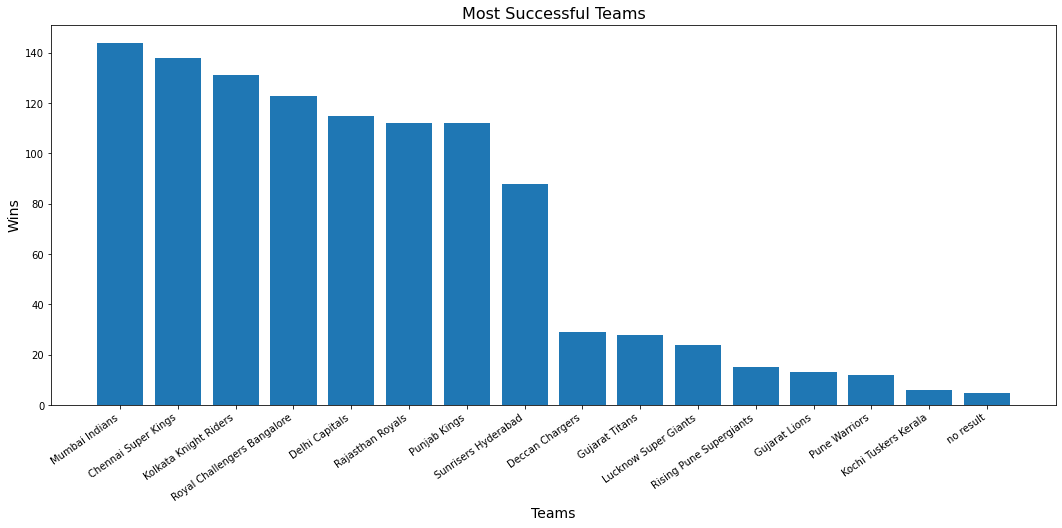

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,7))
plt.bar(Teams, Wins)
plt.xlabel("Teams", fontsize=14)
plt.ylabel("Wins", fontsize=14)
plt.title("Most Successful Teams", fontsize=16)
plt.xticks(rotation=35, ha="right")
# plt.tight_layout()
plt.show()

## **Top Players Analysis**

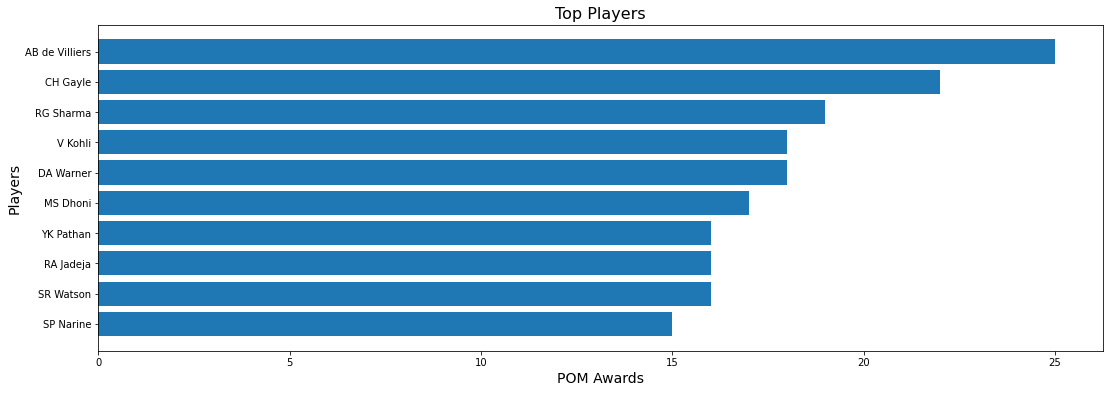

In [153]:
POM_Stats = matches["player_of_match"].value_counts().head(10)
POM_Stats = POM_Stats.sort_values(ascending=True)
Players = list(POM_Stats.index)
No_of_Instances = list(POM_Stats.values)

plt.figure(figsize=(18,6))
plt.barh(Players, No_of_Instances)
plt.xlabel("POM Awards", fontsize=14)
plt.ylabel("Players", fontsize=14)
plt.title("Top Players", fontsize=16)
# plt.xticks(rotation=35, ha="right")
# plt.tight_layout()
plt.show()

In [26]:
deliveries.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


## **Top Batsmen**

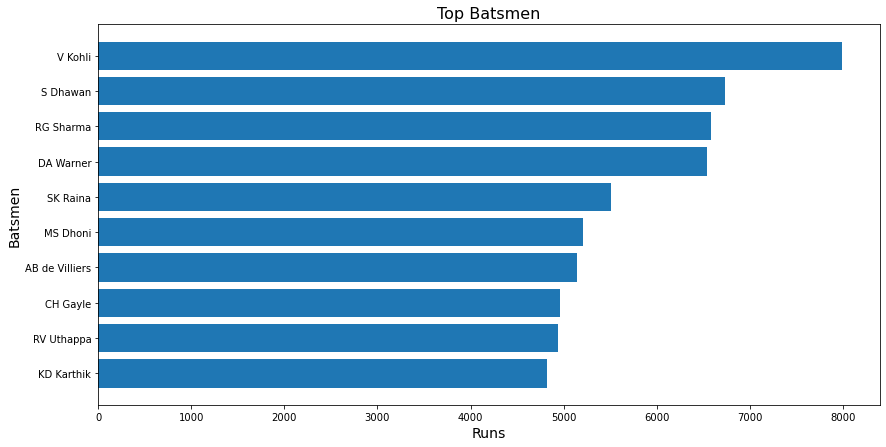

In [155]:
runs_data = deliveries[(deliveries["batsman_runs"]>0) & (deliveries["extra_runs"]==0)]
group_runs = runs_data.groupby("batter")["batsman_runs"].sum()
ordered = group_runs.sort_values(ascending=False).head(10)
ordered = ordered.sort_values(ascending=True)
batsmen = list(ordered.index)
runs = list(ordered.values)
plt.figure(figsize=(14,7))
plt.barh(batsmen, runs)
plt.xlabel("Runs", fontsize=14)
plt.ylabel("Batsmen", fontsize=14)
plt.title("Top Batsmen", fontsize=16)
plt.show()


## **Top Bowlers**

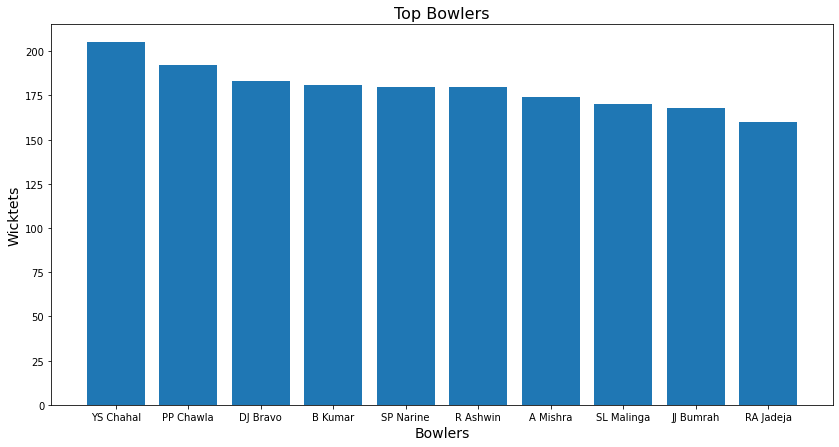

In [156]:
wickets_data = deliveries[(deliveries["is_wicket"]==1) & (deliveries["dismissal_kind"].isin(['caught','bowled','lbw','stumped','caught and bowled','hit wicket']))]
top_bowlers = wickets_data["bowler"].value_counts().head(10)
bowlers = list(top_bowlers.index)
wickets = list(top_bowlers.values)
plt.figure(figsize=(14,7))
plt.bar(bowlers, wickets)
plt.xlabel("Bowlers", fontsize=14)
plt.ylabel("Wicktets", fontsize=14)
plt.title("Top Bowlers", fontsize=16)
plt.show()

## **Top Fielders**

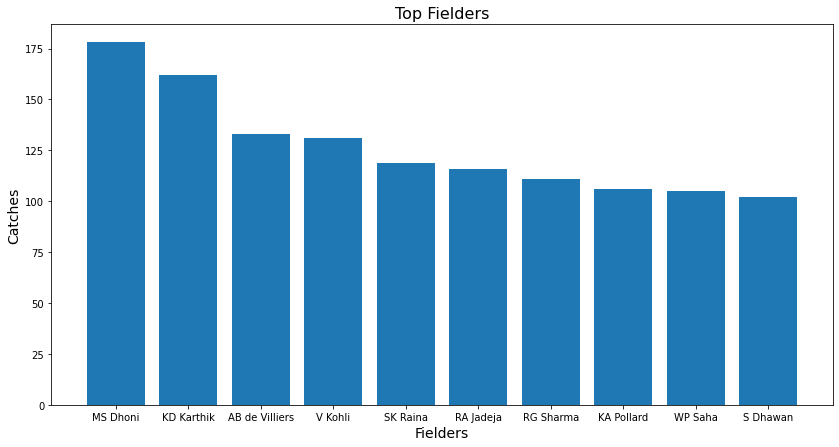

In [157]:
fielders_data = deliveries[(deliveries["is_wicket"]==1) & (deliveries["dismissal_kind"].isin(["caught","run out","caught and bowled"]))]
top_fielders = fielders_data["fielder"].value_counts().head(10)
Fielder = list(top_fielders.index)
catches = list(top_fielders.values)
plt.figure(figsize=(14,7))
plt.bar(Fielder, catches)
plt.xlabel("Fielders", fontsize=14)
plt.ylabel("Catches", fontsize=14)
plt.title("Top Fielders", fontsize=16)
plt.show()
# deliveries[(deliveries["is_wicket"]==1)]["dismissal_kind"].unique()

## **Runs Vs Balls Analysis**

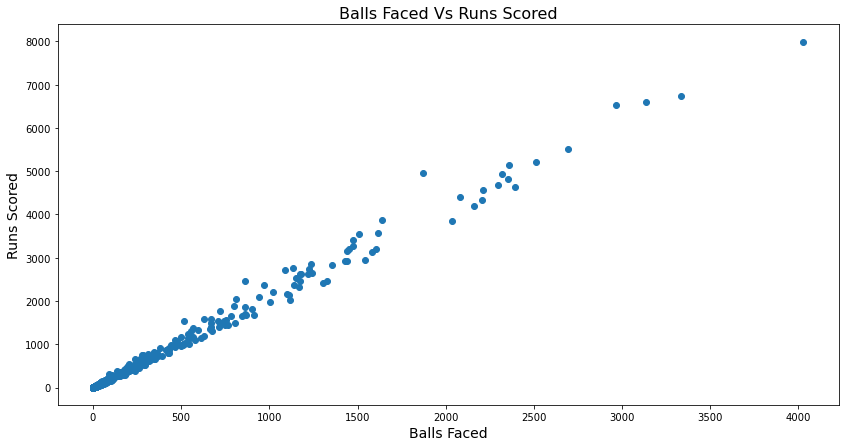

In [158]:
RunsvsBalls_data = deliveries[(deliveries["batsman_runs"]>0) & (deliveries["extra_runs"]==0)]
# Runs1 = list(RunsvsBalls_data.groupby("batter")["batsman_runs"].sum().values)
Runs1 = list(RunsvsBalls_data.groupby("batter")["batsman_runs"].sum().values)
Balls_Faced = list(RunsvsBalls_data.groupby("batter")["ball"].count().values)
plt.figure(figsize=(14,7))
plt.scatter(Balls_Faced, Runs1)
plt.xlabel("Balls Faced", fontsize=14)
plt.ylabel("Runs Scored", fontsize=14)
plt.title("Balls Faced Vs Runs Scored", fontsize=16)
plt.show()

In [31]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [32]:
matches["result_margin"].unique().tolist()

[140.0,
 33.0,
 9.0,
 5.0,
 6.0,
 3.0,
 66.0,
 7.0,
 10.0,
 4.0,
 13.0,
 45.0,
 8.0,
 29.0,
 18.0,
 23.0,
 12.0,
 65.0,
 25.0,
 1.0,
 14.0,
 41.0,
 105.0,
 19.0,
 75.0,
 92.0,
 11.0,
 24.0,
 'None',
 27.0,
 38.0,
 78.0,
 16.0,
 53.0,
 2.0,
 31.0,
 55.0,
 98.0,
 34.0,
 36.0,
 17.0,
 39.0,
 40.0,
 67.0,
 63.0,
 37.0,
 57.0,
 35.0,
 22.0,
 21.0,
 48.0,
 26.0,
 20.0,
 85.0,
 32.0,
 76.0,
 111.0,
 82.0,
 'no result',
 43.0,
 58.0,
 28.0,
 74.0,
 42.0,
 59.0,
 46.0,
 47.0,
 86.0,
 44.0,
 87.0,
 130.0,
 15.0,
 60.0,
 77.0,
 30.0,
 50.0,
 93.0,
 72.0,
 62.0,
 97.0,
 138.0,
 71.0,
 144.0,
 80.0,
 51.0,
 61.0,
 146.0,
 64.0,
 102.0,
 118.0,
 49.0,
 69.0,
 88.0,
 54.0,
 91.0,
 52.0,
 81.0,
 56.0,
 112.0,
 106.0]

In [33]:
total_runs = matches[(matches["target_runs"]!='None') & (~matches["result_margin"].isin(["no result","None"]))]
# total_runs["total_runs_scored"] = 0
total_runs["total_runs_scored"] = np.where(total_runs["result"]=="runs", (total_runs["target_runs"]+(total_runs["target_runs"]-total_runs["result_margin"])), (total_runs["target_runs"]+total_runs["target_runs"]))
total_runs

<ipython-input-33-ad7f1cb7cf76>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_runs["total_runs_scored"] = np.where(total_runs["result"]=="runs", (total_runs["target_runs"]+(total_runs["target_runs"]-total_runs["result_margin"])), (total_runs["target_runs"]+total_runs["target_runs"]))


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,total_runs_scored
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,306.0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,449.0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,260.0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,332.0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,222.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,...,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,430.0
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,320.0
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,...,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,346.0
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,316.0


## **Total runs over Seasons**

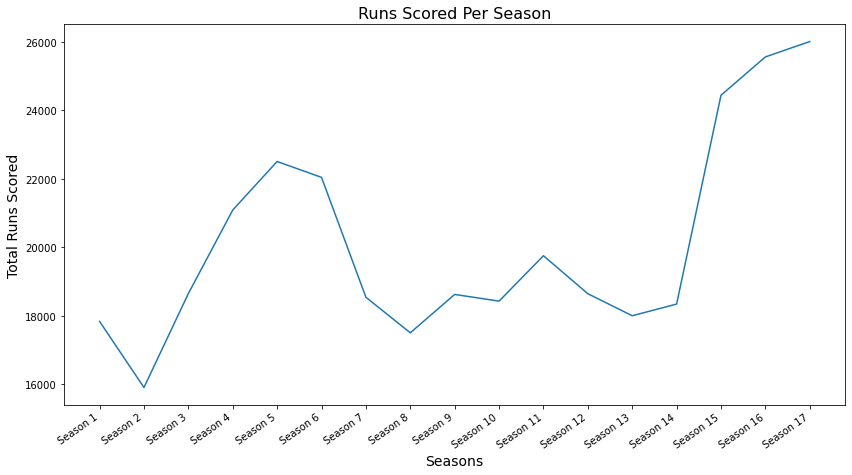

In [159]:
season_runs = total_runs.groupby("season")["total_runs_scored"].sum()
Season = list(season_runs.index)
Runs = list(season_runs.values)
for i in range(len(Season)):
    Season[i] = "Season "+str(i+1)
plt.figure(figsize=(14,7))
plt.plot(Season, Runs)
plt.xlabel("Seasons", fontsize=14)
plt.ylabel("Total Runs Scored", fontsize=14)
plt.title("Runs Scored Per Season", fontsize=16)
plt.xticks(rotation=35, ha="right")
plt.show()

## **Bat Vs Field Proportion**

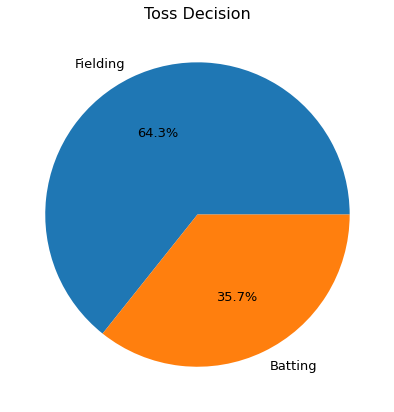

In [163]:
batvsfield = matches["toss_decision"].value_counts()
decision = ["Fielding", "Batting"]
counts = list(batvsfield.values)
plt.figure(figsize=(13,7))
plt.pie(counts, labels=decision, autopct="%1.1f%%", textprops={'fontsize': 13})
plt.title("Toss Decision", fontsize=16)
plt.show()

## **Match Scores Distribution**

<ipython-input-170-39d60bff2ffe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_runs["Avg_runs_scored"] = total_runs["total_runs_scored"]/2


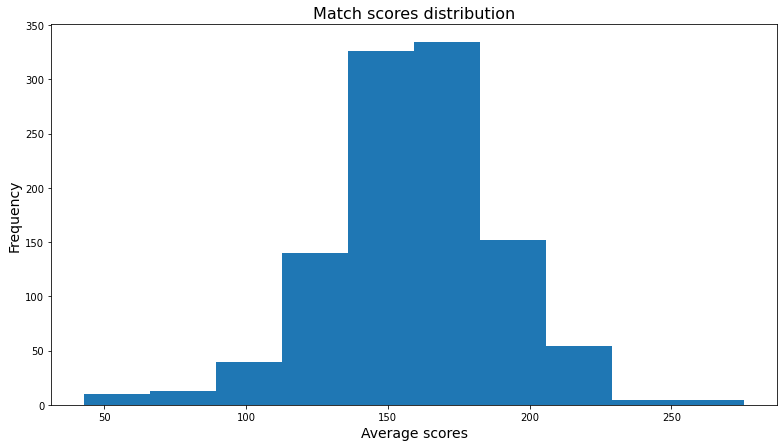

In [170]:
total_runs["Avg_runs_scored"] = total_runs["total_runs_scored"]/2
match_scores = list(total_runs["Avg_runs_scored"].values)
plt.figure(figsize=(13,7))
plt.hist(match_scores, bins=10)
plt.xlabel("Average scores", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Match scores distribution", fontsize=16)
plt.show()

## **Team Dominance Over Time**

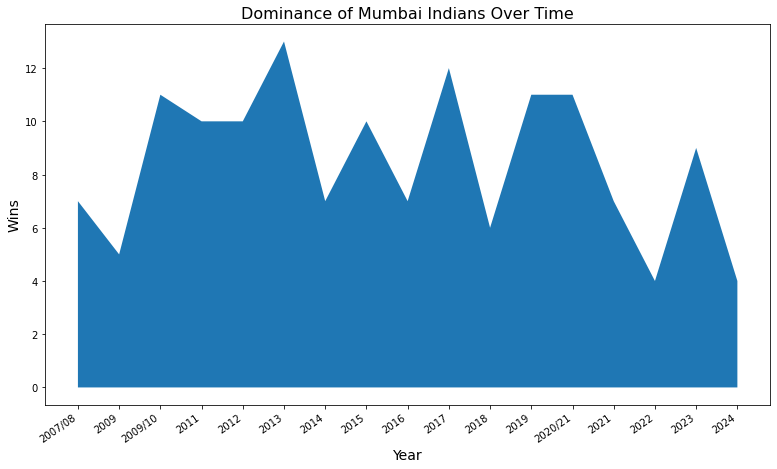

In [165]:
Mumbai = matches[matches["winner"]=="Mumbai Indians"]
Stats_Mumbai = Mumbai["season"].value_counts().sort_index(ascending=True)
Year = list(Stats_Mumbai.index)
Wins = list(Stats_Mumbai.values)
plt.figure(figsize=(13,7))
plt.fill_between(Year, Wins)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Wins", fontsize=14)
plt.title("Dominance of Mumbai Indians Over Time", fontsize=16)
plt.xticks(rotation=35, ha="right")
plt.show()

## Key Insights:
    
    - Mumbai Indians is the most successfull team.
    
    - Top Batsmen usually perform exceptional over all departments due to which they receive most POM Awards.
    
    - Total Runs Scored Per Season increased since 2022 Season as 2 additional teams were added in competition making IPL 
      much bigger and acheiving grand success at world stage compared to other leagues.
      
    - Maximum teams opt to field first after winning the toss since the teams can bat according to the run rate and pitch 
      conditions by having the target to acheive on scoreboard.
    

## Conclusion

This project analyzed IPL data to uncover insights into team performance, player contributions, and match outcomes.

#### Key Findings
     - Mumbai Indians and Chennai Super Kings are the most successfull teams.
     - Top Batsmen usually perform exceptional over all departments due to which they receive most POM Awards.
     - Scoring trends have increased over time, especially in death overs

    
This pattern suggests that IPL has became more and more popular in the world as the season progresses where top international players play in the 
tournament for different teams. Most of the teams give tough competition to opponent teams by chasing bigger totals or by 
defending lower totals making it a nail biter. The tournament will get much more exciting and famous as the Season iterations
goes on increasing.